NOORIN NASHIKA M - 24BAD084

SCENARIO 1: KNN Classification



Saving breast-cancer.csv to breast-cancer.csv
Best K: 9

Accuracy: 0.9298245614035088

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.94      0.94        71
           1       0.91      0.91      0.91        43

    accuracy                           0.93       114
   macro avg       0.93      0.93      0.93       114
weighted avg       0.93      0.93      0.93       114



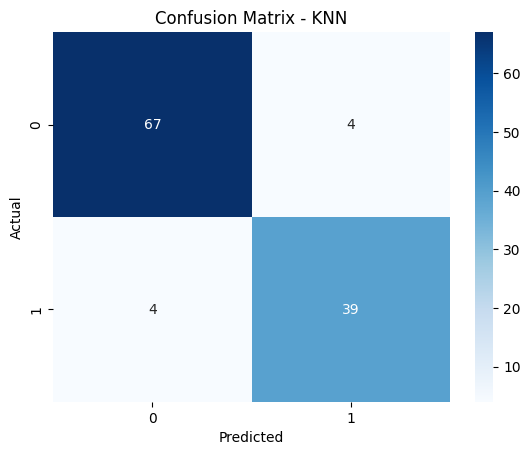

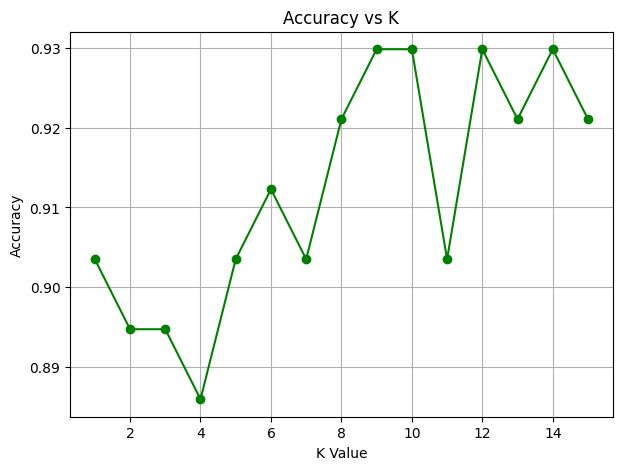

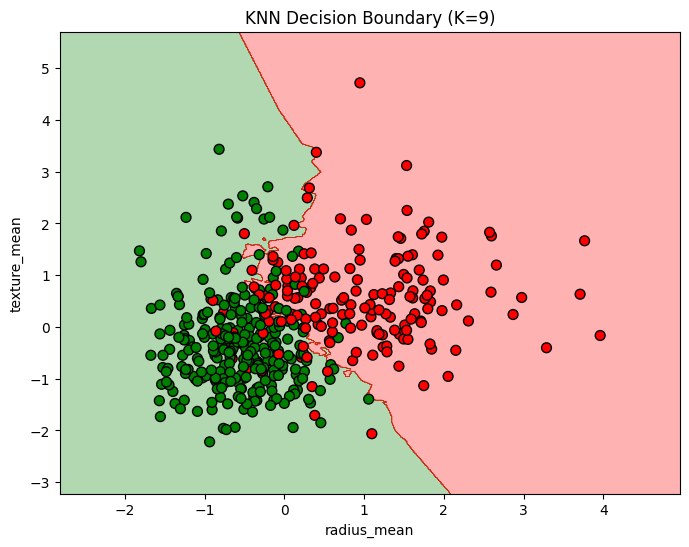

In [2]:
print("NOORIN NASHIKA M - 24BAD084")
print("\nSCENARIO 1: KNN Classification\n")
from google.colab import files
uploaded = files.upload()
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.model_selection import train_test_split

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from matplotlib.colors import ListedColormap

#Load Dataset

df = pd.read_csv("breast-cancer.csv")

#Check columns

#print(df.columns)

#Encode target variable

le = LabelEncoder()

df['diagnosis'] = le.fit_transform(df['diagnosis'])  # Benign=0, Malignant=1

#Select two features for visualization (Decision Boundary)

features = ['radius_mean', 'texture_mean']  # make sure these exist in CSV

X = df[features]

y = df['diagnosis']

#Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(

    X, y, test_size=0.2, random_state=42)

#Feature Scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

#Experiment with different K

accuracy_list = []

k_range = range(1, 16)

for k in k_range:

    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train_scaled, y_train)

    y_pred = knn.predict(X_test_scaled)

    accuracy_list.append(accuracy_score(y_test, y_pred))

#Best K

best_k = k_range[np.argmax(accuracy_list)]

print("Best K:", best_k)

#Train final model with best K

knn = KNeighborsClassifier(n_neighbors=best_k)

knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)

#Evaluation

print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

#Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - KNN")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

#Accuracy vs K Plot

plt.figure(figsize=(7,5))

plt.plot(k_range, accuracy_list, marker='o', color='green')

plt.title("Accuracy vs K")

plt.xlabel("K Value")

plt.ylabel("Accuracy")

plt.grid(True)

plt.show()

#Decision Boundary (2 features)

X_set, y_set = X_train_scaled, y_train

X1, X2 = np.meshgrid(

    np.arange(X_set[:, 0].min()-1, X_set[:, 0].max()+1, 0.01),

    np.arange(X_set[:, 1].min()-1, X_set[:, 1].max()+1, 0.01)

)

plt.figure(figsize=(8,6))

plt.contourf(

    X1, X2,

    knn.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),

    alpha=0.3,

    cmap=ListedColormap(('green', 'red'))

)

plt.scatter(X_set[:, 0], X_set[:, 1], c=y_set, s=50, edgecolor='k', cmap=ListedColormap(('green', 'red')))

plt.title(f"KNN Decision Boundary (K={best_k})")

plt.xlabel(features[0])

plt.ylabel(features[1])

plt.show()


